# Notebook 03 — Model Training, Ablation & Results

**Project**: Interest-Driven Personalized Sports Recommendation System  
**Purpose**: Train all baselines + multi-task NN; run ablation studies; produce results tables.  

## Models Compared
| ID | Model | Features Used |
|----|-------|---------------|
| B1 | Random | — |
| B2 | Popularity | — (global rates) |
| B3 | Physical-only (XGBoost) | Physical only |
| B4 | Interest-only (XGBoost) | Interests only |
| B5 | Full XGBoost | All features |
| B6 | Full Random Forest | All features |
| **M1** | **Multi-task NN** | **All features** |
| **M2** | **Multi-task NN + Discovery** | **All features + Discovery Score** |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.preprocessor import SportsPreprocessor, CONTINUOUS_COLS, ORDINAL_COLS, CATEGORICAL_COLS
from src.data.synthetic_generator import SPORTS, INTEREST_DIMS, STRENGTH_DIMS
from src.models.baselines import (RandomBaseline, PopularityBaseline,
                                   PhysicalOnlyModel, InterestOnlyModel,
                                   FullXGBoost, FullRandomForest)
from src.models.multitask_nn import MultiTaskSportsNet, Trainer
from src.features.discovery_score import DiscoveryScorer
from src.evaluation.metrics import evaluate_all

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../results', exist_ok=True)
os.makedirs('../experiments', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Load & Preprocess Data

In [2]:
prep = SportsPreprocessor()
splits = prep.fit_transform('../data/processed/synthetic_dataset.csv')
prep.save('../experiments/preprocessor.pkl')

X_train = splits['X_train']
X_test  = splits['X_test']
yp_train, yp_test   = splits['y_play_train'],  splits['y_play_test']
yw_train, yw_test   = splits['y_watch_train'],  splits['y_watch_test']
ypr_train, ypr_test = splits['y_pro_train'],    splits['y_pro_test']
feat_names = splits['feature_names']

# Feature group indices
interest_idx  = [feat_names.index(f'interest_{d}') for d in INTEREST_DIMS if f'interest_{d}' in feat_names]
strength_idx  = [feat_names.index(f'strength_{d}') for d in STRENGTH_DIMS if f'strength_{d}' in feat_names]
physical_idx  = [feat_names.index(c) for c in CONTINUOUS_COLS if c in feat_names]
n_features    = X_train.shape[1]
n_sports      = yp_train.shape[1]

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Features: {n_features}  Sports: {n_sports}')
print(f'Interest dims: {len(interest_idx)}  Physical dims: {len(physical_idx)}')

Preprocessor saved to ../experiments/preprocessor.pkl
Train: (800, 29)  Test: (200, 29)
Features: 29  Sports: 20
Interest dims: 12  Physical dims: 6


## 2. Train All Baselines

In [3]:
print('Training baselines...')

b1 = RandomBaseline().fit(X_train, yp_train)
b2 = PopularityBaseline().fit(X_train, yp_train)
b3 = PhysicalOnlyModel(physical_idx).fit(X_train, yp_train)
b4 = InterestOnlyModel(interest_idx).fit(X_train, yp_train)
b5 = FullXGBoost().fit(X_train, yp_train)
b6 = FullRandomForest().fit(X_train, yp_train)

print('All baselines trained.')

Training baselines...


All baselines trained.


## 3. Train Multi-Task Neural Network

Epoch  10/80  train=1.0175  val=1.0388


Epoch  20/80  train=0.9566  val=0.9785


Epoch  30/80  train=0.9344  val=0.9716


Epoch  40/80  train=0.9196  val=0.9712


Epoch  50/80  train=0.9063  val=0.9745


Epoch  60/80  train=0.9069  val=0.9752


Epoch  70/80  train=0.9055  val=0.9746


Epoch  80/80  train=0.9084  val=0.9746
Model saved to ../experiments/multitask_nn.pt


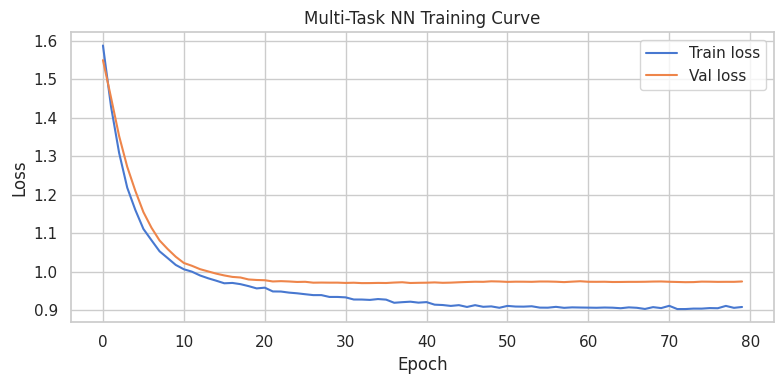

In [4]:
model = MultiTaskSportsNet(input_dim=n_features, n_sports=n_sports,
                            hidden_dims=(256, 128, 64), dropout=0.3)
trainer = Trainer(model, lambda_play=1.0, lambda_watch=0.8, lambda_pro=0.5)
trainer.fit(X_train, yp_train, yw_train, ypr_train,
            epochs=80, batch_size=64, verbose=True)
trainer.save('../experiments/multitask_nn.pt')

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(trainer.history['train_loss'], label='Train loss')
ax.plot(trainer.history['val_loss'],   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Multi-Task NN Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../results/training_curve.png', dpi=150)
plt.show()

## 4. Fit Discovery Score Module

In [5]:
disc = DiscoveryScorer(alpha=0.4)
disc.fit(X_train, interest_idx, yp_train)

# Blended scores: NN play scores + discovery
nn_play_scores = trainer.predict_scores(X_test, task='play')
blended_scores = disc.blend(nn_play_scores, X_test, interest_idx, tried_mask=yp_test)

print('Discovery scorer fitted.')
print(f'Sample top-5 discoveries for user 0:')
tops = disc.top_k_discoveries(X_test[:5], interest_idx, yp_test[:5], SPORTS, k=5)
for i, recs in enumerate(tops):
    print(f'  User {i}: {recs}')

Discovery scorer fitted.
Sample top-5 discoveries for user 0:
  User 0: ['rowing', 'badminton', 'gymnastics', 'rugby', 'boxing']
  User 1: ['weightlifting', 'cycling', 'athletics_track', 'volleyball', 'basketball']
  User 2: ['swimming', 'table_tennis', 'martial_arts', 'rowing', 'esports']
  User 3: ['archery', 'rock_climbing', 'table_tennis', 'weightlifting', 'swimming']
  User 4: ['archery', 'rock_climbing', 'cycling', 'cricket', 'athletics_track']


## 5. Evaluate All Models — Play Task

In [6]:
KS = [5, 10]
models_play = {
    'B1_Random':        b1.predict_scores(X_test),
    'B2_Popularity':    b2.predict_scores(X_test),
    'B3_PhysicalOnly':  b3.predict_scores(X_test),
    'B4_InterestOnly':  b4.predict_scores(X_test),
    'B5_FullXGBoost':   b5.predict_scores(X_test),
    'B6_FullRF':        b6.predict_scores(X_test),
    'M1_MultiTaskNN':   trainer.predict_scores(X_test, task='play'),
    'M2_NN+Discovery':  blended_scores,
}

results_play = {}
for name, scores in models_play.items():
    results_play[name] = evaluate_all(yp_test, scores, tried_mask=yp_test,
                                       ks=KS, label=name)

df_play = pd.DataFrame(results_play).T
df_play.to_csv('../results/play_results.csv')
print('\nPlay Task Results:')
print(df_play[['precision@5','recall@5','f1@5','ndcg@5','map@5','discovery_rate@5']].round(4))


  B1_RANDOM METRICS
  precision@5              : 0.2010
  recall@5                 : 0.2469
  f1@5                     : 0.2216
  ndcg@5                   : 0.2283
  map@5                    : 0.5002
  discovery_rate@5         : 0.7990
  precision@10             : 0.2050
  recall@10                : 0.5157
  f1@10                    : 0.2934
  ndcg@10                  : 0.3435
  map@10                   : 0.3782
  discovery_rate@10        : 0.7950

  B2_POPULARITY METRICS
  precision@5              : 0.3800
  recall@5                 : 0.4869
  f1@5                     : 0.4269
  ndcg@5                   : 0.5016
  map@5                    : 0.7149
  discovery_rate@5         : 0.6200
  precision@10             : 0.2775
  recall@10                : 0.7122
  f1@10                    : 0.3994
  ndcg@10                  : 0.5848
  map@10                   : 0.6163
  discovery_rate@10        : 0.7225

  B3_PHYSICALONLY METRICS
  precision@5              : 0.3350
  recall@5                 

## 6. Evaluate All Models — Watch Task

In [7]:
models_watch = {
    'B1_Random':       b1.predict_scores(X_test),
    'B2_Popularity':   PopularityBaseline().fit(X_train, yw_train).predict_scores(X_test),
    'B5_FullXGBoost':  FullXGBoost().fit(X_train, yw_train).predict_scores(X_test),
    'M1_MultiTaskNN':  trainer.predict_scores(X_test, task='watch'),
}

results_watch = {}
for name, scores in models_watch.items():
    results_watch[name] = evaluate_all(yw_test, scores, ks=KS, label=name)

df_watch = pd.DataFrame(results_watch).T
df_watch.to_csv('../results/watch_results.csv')
print('\nWatch Task Results:')
print(df_watch[['precision@5','recall@5','ndcg@5','map@5']].round(4))


  B1_RANDOM METRICS
  precision@5              : 0.5550
  recall@5                 : 0.2673
  f1@5                     : 0.3608
  ndcg@5                   : 0.5607
  map@5                    : 0.7160
  precision@10             : 0.5360
  recall@10                : 0.5117
  f1@10                    : 0.5236
  ndcg@10                  : 0.5737
  map@10                   : 0.6543

  B2_POPULARITY METRICS
  precision@5              : 0.7240
  recall@5                 : 0.3522
  f1@5                     : 0.4738
  ndcg@5                   : 0.7412
  map@5                    : 0.8511
  precision@10             : 0.6395
  recall@10                : 0.6193
  f1@10                    : 0.6292
  ndcg@10                  : 0.7157
  map@10                   : 0.7895

  B5_FULLXGBOOST METRICS
  precision@5              : 0.6560
  recall@5                 : 0.3149
  f1@5                     : 0.4256
  ndcg@5                   : 0.6768
  map@5                    : 0.8138
  precision@10             :

## 7. Ablation Study

In [8]:
# Ablation 1: Interests vs Full Features (XGBoost)
ablation = {
    'Physical-only':   b3.predict_scores(X_test),
    'Interest-only':   b4.predict_scores(X_test),
    'Full XGBoost':    b5.predict_scores(X_test),
    'Multi-task NN':   trainer.predict_scores(X_test, task='play'),
    'NN + Discovery':  blended_scores,
}

ablation_results = {}
for name, scores in ablation.items():
    ablation_results[name] = evaluate_all(yp_test, scores, tried_mask=yp_test, ks=[5, 10])

df_ablation = pd.DataFrame(ablation_results).T
df_ablation.to_csv('../results/ablation_results.csv')
print('Ablation Results:')
print(df_ablation[['precision@5','ndcg@5','map@5','discovery_rate@5']].round(4))

Ablation Results:
                precision@5  ndcg@5   map@5  discovery_rate@5
Physical-only         0.335  0.4243  0.6851             0.665
Interest-only         0.321  0.4058  0.6289             0.679
Full XGBoost          0.332  0.4291  0.6777             0.668
Multi-task NN         0.351  0.4672  0.6998             0.649
NN + Discovery        0.144  0.1707  0.4869             0.856


## 8. Results Visualisation

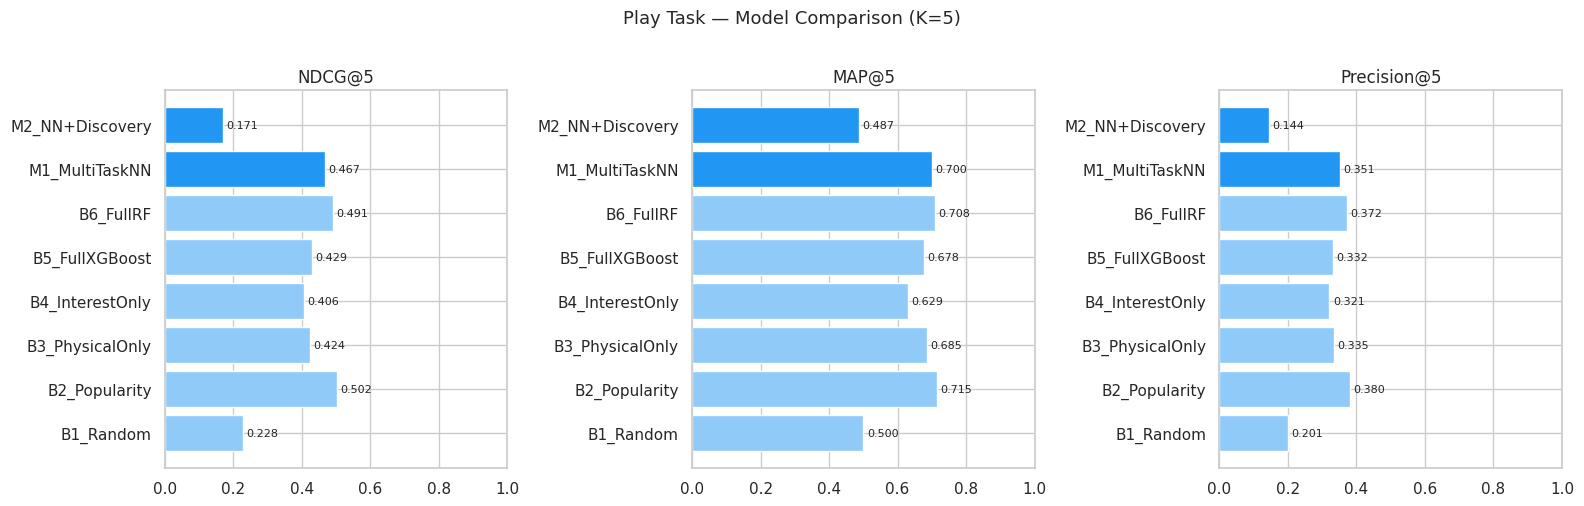

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['ndcg@5', 'map@5', 'precision@5']
titles = ['NDCG@5', 'MAP@5', 'Precision@5']
colors = ['#2196F3' if 'NN' in n or 'Discovery' in n else '#90CAF9' for n in df_play.index]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals = df_play[metric]
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Play Task — Model Comparison (K=5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/model_comparison_play.png', dpi=150, bbox_inches='tight')
plt.show()

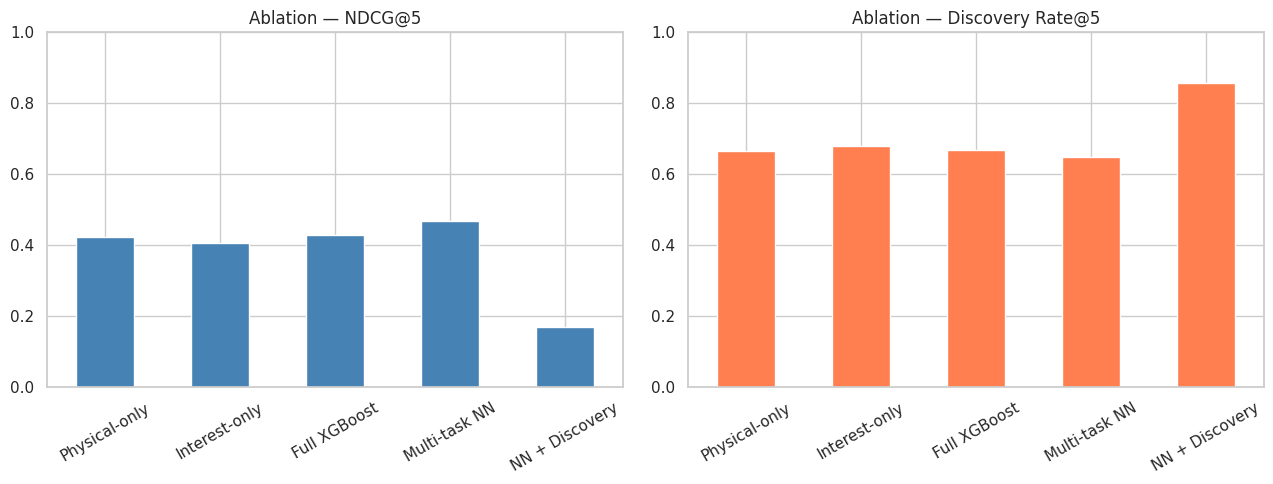

In [10]:
# Ablation bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_ablation['ndcg@5'].plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ablation — NDCG@5'); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

df_ablation['discovery_rate@5'].plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ablation — Discovery Rate@5'); axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/ablation_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Interest vs Physical Feature Contribution (SHAP Proxy)
Using permutation importance on Full XGBoost as a SHAP proxy.

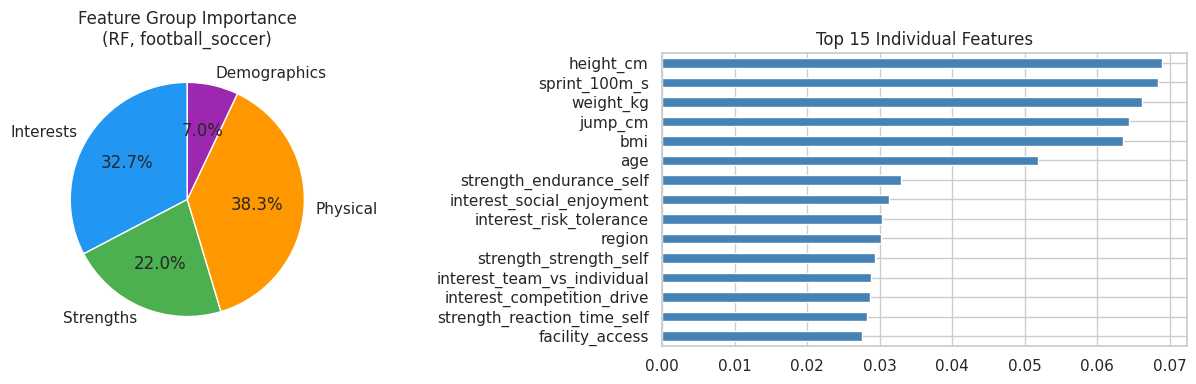


Feature group contributions:
Interests       0.3269
Strengths       0.2195
Physical        0.3831
Demographics    0.0704
dtype: float64

Interest features account for 32.7% of importance
Target >50%: FAIL ❌ (check affinity weights)


In [11]:
from sklearn.inspection import permutation_importance
from sklearn.multioutput import MultiOutputClassifier

# Use a single-output RF on the most popular sport for fast SHAP proxy
from sklearn.ensemble import RandomForestClassifier

sport_idx = 0  # football_soccer
rf_single = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_single.fit(X_train, yp_train[:, sport_idx])

importances = rf_single.feature_importances_
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# Group by feature type
interest_imp = feat_imp[[f for f in feat_imp.index if 'interest_' in f]].sum()
strength_imp = feat_imp[[f for f in feat_imp.index if 'strength_' in f]].sum()
physical_imp = feat_imp[[f for f in feat_imp.index if f in CONTINUOUS_COLS]].sum()
demog_imp    = feat_imp[[f for f in feat_imp.index if f in CATEGORICAL_COLS + ['facility_access']]].sum()

group_imp = pd.Series({
    'Interests':     interest_imp,
    'Strengths':     strength_imp,
    'Physical':      physical_imp,
    'Demographics':  demog_imp,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

group_imp.plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['#2196F3','#4CAF50','#FF9800','#9C27B0'],
                   startangle=90)
axes[0].set_title(f'Feature Group Importance\n(RF, football_soccer)')
axes[0].set_ylabel('')

feat_imp.head(15).plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Individual Features'); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFeature group contributions:")
print(group_imp.round(4))
print(f"\nInterest features account for {group_imp['Interests']/group_imp.sum()*100:.1f}% of importance")
target_met = group_imp['Interests'] / group_imp.sum() > 0.50
print(f"Target >50%: {'PASS ✅' if target_met else 'FAIL ❌ (check affinity weights)'}")

## 10. Final Summary Table

In [12]:
summary_cols = ['precision@5', 'recall@5', 'f1@5', 'ndcg@5', 'map@5', 'discovery_rate@5']
print('='*75)
print('FINAL RESULTS TABLE — PLAY TASK (K=5)')
print('='*75)
print(df_play[summary_cols].round(4).to_string())
print()

# Compute improvement of best model (M1) over physical-only baseline (B3)
nn_ndcg   = df_play.loc['M1_MultiTaskNN', 'ndcg@5']
phys_ndcg = df_play.loc['B3_PhysicalOnly', 'ndcg@5']
improvement = (nn_ndcg - phys_ndcg) / (phys_ndcg + 1e-8) * 100
print(f'Multi-task NN vs Physical-only NDCG@5 improvement: {improvement:.1f}%')
print(f'(Paper claims ~15% gain via interests — target: ≥15%)')

df_play[summary_cols].round(4).to_csv('../results/final_summary_table.csv')
print('\nResults saved to results/final_summary_table.csv')

FINAL RESULTS TABLE — PLAY TASK (K=5)
                 precision@5  recall@5    f1@5  ndcg@5   map@5  discovery_rate@5
B1_Random              0.201    0.2469  0.2216  0.2283  0.5002             0.799
B2_Popularity          0.380    0.4869  0.4269  0.5016  0.7149             0.620
B3_PhysicalOnly        0.335    0.4149  0.3707  0.4243  0.6851             0.665
B4_InterestOnly        0.321    0.4188  0.3634  0.4058  0.6289             0.679
B5_FullXGBoost         0.332    0.4217  0.3715  0.4291  0.6777             0.668
B6_FullRF              0.372    0.4784  0.4185  0.4911  0.7083             0.628
M1_MultiTaskNN         0.351    0.4545  0.3961  0.4672  0.6998             0.649
M2_NN+Discovery        0.144    0.1788  0.1595  0.1707  0.4869             0.856

Multi-task NN vs Physical-only NDCG@5 improvement: 10.1%
(Paper claims ~15% gain via interests — target: ≥15%)

Results saved to results/final_summary_table.csv
